In [79]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeKyoto as Fake 
from qiskit_ibm_runtime import SamplerV2 as Sampler #new version

import matplotlib.pyplot as plt
import numpy as np
import scipy

In [107]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="qiskit")

We have a full superposition |phi> = alpha|0> + beta|1>

A qubit can be represented on the Bloch Sphere:

|0> - north pole
|1> - south pole

|phi> = cos(theta/2)|0> + exp(iphi)(theta/0)|1>

a. pure states (Bloch Sphere) -> rho = |phi> < phi| =1/2 (1 + vec_a * sigma), sigma = (sigma_x, sigma_y, sigma_z)
2x2 Matrix

b. classical (p - probability of |1>, so 1-p is probability of |0>)
-> rho = p([0, 0], [0, 1]) + (1-p) ([1, 0], [0, 0]) = ([p, 0], [0, 1-p])

c. mixed pho_zx |vec_a| < 1

Noise destroys both probability and global phase

State 1 is excited. We are looking at in in a rotating plane & do not see trivial evoluation.

|1> - E1
|0> - E0 (ground state)

|1> (south) -> \0> (north) RELAXATION (rotation of x or y axis), so longitudal relaxation comes from transversial noise

For our superconducting quibit the excitation energy decay is practically 0

Formula:

1/T1 = takie odwrotne L, 1 down

Uniform noise - same along all axes (transverse noise on X and Y + longitudal noise on Z)
It couses both relaxation and decoherence

1/T2 = 1/ (2 T1) + 1/T_phi, with fundamental limit T2 <= 2T1

 Concrary, longitudal noise changes the phase of the superposition causing rotating of z axis. Associated decay is dephacing time. time decay T_phi - loss of phase information

BLOCH-REDFIELD MODEL (phenomenological model)

we start with the basic state and with evolution in time, the state is influenced by uniform noise (T1 and T2) (formula on slide 9)

We must assume that noise id weakly coupled to qubit (short correlation times)

Due to Bloch Spere projection characteristycs, in the experiment we need to intentionally detune with respect to the rotating frame delta*omega (we are observing the BS sitting on it, rotating with freq in tune with the qubit)

Noise on easy 2-qubit level is way more comlicated in QC that regular C

T1 RELAXATION TIME

|0> - x gate - |1> - readaout (the probability should decay in time) - T1// purely classical process

RAMSEY EXPERIMENT (T2*)

what happend in teh transversal direction of the BS?

|0> - Rx(pi/2) (transversal plane) - |1> - readout

We want to seperate the relaxation effects by applying convolution of decay with oscillation

SPIN ECHO EXPERIMENT (T2e)// 

Slowly fluctuating low frequency noise will be cancelled because of the flip to anotehr side of the plane 

T2 makes the system less and less quantum

In [80]:
noise_model = NoiseModel.from_backend(
    Fake(), thermal_relaxation = True, gate_error = True, readout_error = True)

aer_backend = AerSimulator.from_backend(Fake(), noise_model = noise_model)

In [81]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm = generate_preset_pass_manager(backend = aer_backend, 
                                  optimization_level = 1,
                                  scheduling_method = 'asap')

In [157]:
def exp_decay(x, a, tau, b):
    return a * np.exp(-x / tau) + b

def ramsey_fit(x, a, tau, b, f, phi):
    envelope = exp_decay(x, a, tau, 0)
    return envelope * np.cos(2 * np.pi * f * x + phi) + b

In [104]:
def parse_counts(counts, nshots=10000):
    prob_1 = 0
    for out, count in counts.items():
        values = [1 if bit == '0' else 0 for bit in list(out)]
        prob_1 += np.sum(values) * (count / nshots)
        
    return prob_1


## Task 1

In [108]:
Niter = 250 

delay_times = np.linspace(0, 250e-6, Niter) 
circuits = []

for tau in delay_times:
    qc = QuantumCircuit(1)
    
    qc.x(0)
    qc.barrier()
    
    qc.delay(tau, 0, unit='s')
    qc.barrier()
    
    qc.measure_all()
    
    circuits.append(qc)

isa_circuits = pm.run(circuits)

In [105]:
sampler = Sampler(mode = aer_backend)
job = sampler.run(isa_circuits, shots = 10000)

results = job.result()
T1_tab = []
for n, result in enumerate(results):
    counts = result.data.meas.get_counts()
    T1_tab.append(parse_counts(counts))

Wyznaczony z dopasowania T1: 123.37 mikrosekund


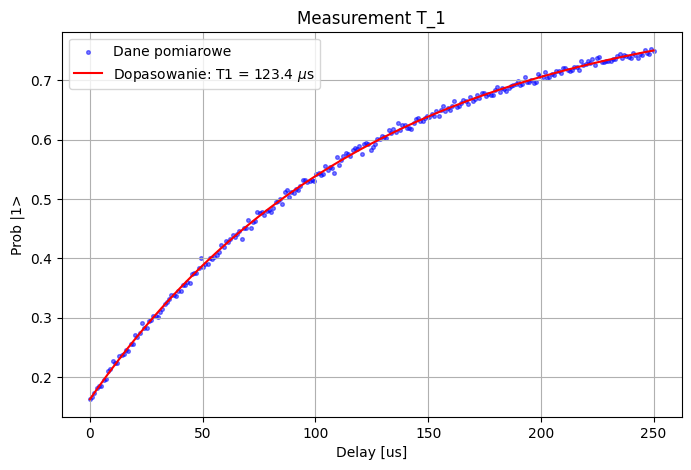

In [162]:
p0 = [1, 250e-6, 0.1]

popt, _ = scipy.optimize.curve_fit(exp_decay, delay_times, T1_tab, p0=p0)

A_fit, T1_fit, C_fit = popt

print(f"Wyznaczony z dopasowania T1: {T1_fit * 1e6:.2f} mikrosekund")


smooth_times = np.linspace(0, 250e-6, 100)
fitted_curve = exp_decay(smooth_times, A_fit, T1_fit, C_fit)

plt.figure(figsize=(8, 5))
plt.scatter(delay_times * 1e6, T1_tab, label='Dane pomiarowe', color='blue', alpha=0.5, s=7)
plt.plot(smooth_times * 1e6, fitted_curve, label=f'Dopasowanie: T1 = {T1_fit*1e6:.1f} $\mu$s', color='red')

plt.title("Measurement T_1")
plt.xlabel("Delay [us]")
plt.ylabel("Prob |1>")
plt.legend()
plt.grid(True)
plt.show()

## Task 2

In [191]:
Niter = 250 

delay_times = np.linspace(0, 100e-6, Niter) 
theta = 2*np.pi*10*10e3*delay_times 
circuits2 = []

for tau in delay_times:
    qc = QuantumCircuit(1)
    theta = 2*np.pi*10*10e3*tau

    qc.rx(np.pi/2, 0)
    qc.barrier()
    qc.delay(tau, 0, unit='s')
    qc.barrier()
    qc.rz(theta, 0)
    qc.rx(np.pi/2, 0)
    
    qc.measure_all()
    
    circuits2.append(qc)

isa_circuits2 = pm.run(circuits2)

In [192]:
sampler = Sampler(mode = aer_backend)
job = sampler.run(isa_circuits2, shots = 10000)

results = job.result()
T2_tab = []
for n, result in enumerate(results):
    counts = result.data.meas.get_counts()
    T2_tab.append(parse_counts(counts))

Wyznaczony z dopasowania T2*: 24.04 mikrosekund
Rzeczywista częstotliwość: 99.97 kHz


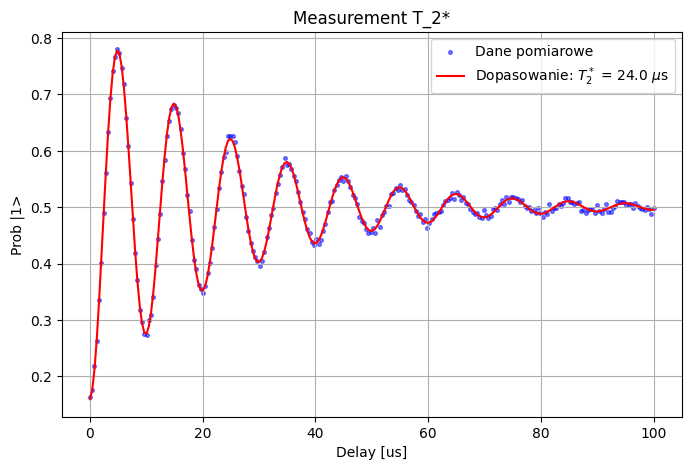

In [193]:
p0 = [0.5, 100e-6, 0.5, 100e3, 0]

popt, _ = scipy.optimize.curve_fit(ramsey_fit, delay_times, T2_tab, p0=p0, maxfev=10000)

A_fit, T2_fit, C_fit, f_fit, phi_fit = popt

print(f"Wyznaczony z dopasowania T2*: {T2_fit * 1e6:.2f} mikrosekund")
print(f"Rzeczywista częstotliwość: {f_fit / 1000:.2f} kHz")

smooth_times = np.linspace(0, max(delay_times), 250)
fitted_curve = ramsey_fit(smooth_times, *popt)  

# 4. Generowanie wykresu
plt.figure(figsize=(8, 5))
# Zwróć uwagę: rysujemy T2_tab!
plt.scatter(delay_times * 1e6, T2_tab, label='Dane pomiarowe', color='blue', alpha=0.5, s=7)
plt.plot(smooth_times * 1e6, fitted_curve, label=f'Dopasowanie: $T_2^*$ = {T2_fit*1e6:.1f} $\mu$s', color='red')

plt.title("Measurement T_2*")
plt.xlabel("Delay [us]")
plt.ylabel("Prob |1>")
plt.legend()
plt.grid(True)
plt.show()

In [194]:
Niter = 250 

delay_times = np.linspace(0, 250e-6, Niter) 
circuits3 = []

for tau in delay_times:
    qc = QuantumCircuit(1)

    qc.rx(np.pi/2, 0)
    qc.barrier()
    qc.delay(tau/2, 0, unit='s')
    qc.barrier()
    qc.rx(np.pi, 0)
    qc.barrier()
    qc.delay(tau/2, 0, unit='s')
    qc.barrier()
    qc.rx(np.pi/2, 0)

    qc.measure_all()
    
    circuits3.append(qc)

isa_circuits3 = pm.run(circuits3)

In [195]:
sampler = Sampler(mode = aer_backend)
job = sampler.run(isa_circuits3, shots = 10000)

results = job.result()
T3_tab = []
for n, result in enumerate(results):
    counts = result.data.meas.get_counts()
    T3_tab.append(parse_counts(counts))

Wyznaczony z dopasowania T2e: 24.47 mikrosekund


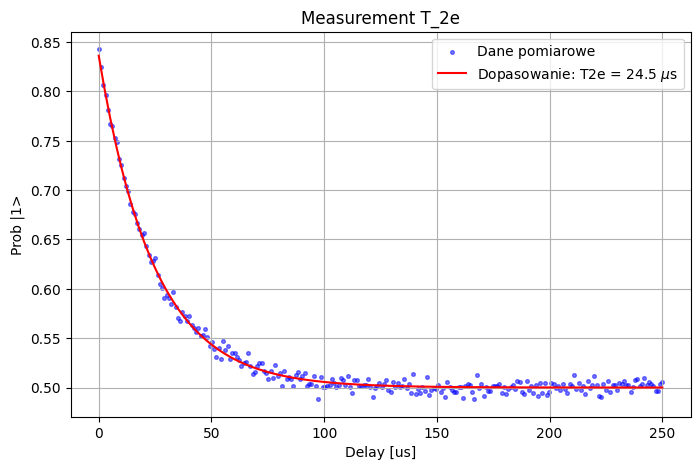

In [196]:
p0 = [1, 250e-6, 0.1]

popt, _ = scipy.optimize.curve_fit(exp_decay, delay_times, T3_tab, p0=p0)

A_fit, T3_fit, C_fit = popt

print(f"Wyznaczony z dopasowania T2e: {T3_fit * 1e6:.2f} mikrosekund")


smooth_times = np.linspace(0, 250e-6, 100)
fitted_curve = exp_decay(smooth_times, A_fit, T3_fit, C_fit)

plt.figure(figsize=(8, 5))
plt.scatter(delay_times * 1e6, T3_tab, label='Dane pomiarowe', color='blue', alpha=0.5, s=7)
plt.plot(smooth_times * 1e6, fitted_curve, label=f'Dopasowanie: T2e = {T3_fit*1e6:.1f} $\mu$s', color='red')

plt.title("Measurement T_2e")
plt.xlabel("Delay [us]")
plt.ylabel("Prob |1>")
plt.legend()
plt.grid(True)
plt.show()